In [1]:
%run setup.py

import ydf
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import LeaveOneGroupOut
import matplotlib.pyplot as plt

ds = pd.read_csv("../data/DogFeatures.csv")

In [10]:
def lodo_validation(dataset, learner):
    logo = LeaveOneGroupOut()
    group = dataset["DogID"]
    X = dataset.drop(columns=["DogID", "label"])
    y = dataset["label"]

    accuracies = []
    f1_scores = []
    matrices = []

    classes = sorted(dataset["label"].unique())

    for train_ix, test_ix in logo.split(X, y, groups=group):
        train_df = dataset.iloc[train_ix]
        test_df = dataset.iloc[test_ix]

        test_subject = test_df["DogID"].iloc[0]

        train_df = train_df.drop(columns=["DogID"])
        test_df = test_df.drop(columns=["DogID"])

        model = learner.train(train_df, verbose=0)

        probs = model.predict(test_df)
        preds = np.argmax(probs, axis=1)

        model_classes = model.label_classes()
        preds_labels = np.array([model_classes[int(i)] for i in preds])

        y_true = test_df["label"].values

        acc = accuracy_score(y_true, preds_labels)
        f1_weighted = f1_score(y_true, preds_labels, average="weighted")
        f1_macro = f1_score(y_true, preds_labels, average="macro")

        accuracies.append(acc)
        f1_scores.append((f1_weighted, f1_macro))

        cm = confusion_matrix(y_true, preds_labels, labels=classes)
        matrices.append(cm)

    return accuracies, f1_scores, matrices, classes

In [11]:
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

def lodo_validation_sampling(dataset, learner, sampling=None, random_state=42):
    logo = LeaveOneGroupOut()
    group = dataset["DogID"]
    X = dataset.drop(columns=["DogID", "label"])
    y = dataset["label"]

    accuracies = []
    f1_scores = []
    matrices = []

    classes = sorted(dataset["label"].unique())

    for train_ix, test_ix in logo.split(X, y, groups=group):
        train_df = dataset.iloc[train_ix].copy()
        test_df = dataset.iloc[test_ix].copy()

        X_train = train_df.drop(columns=["DogID", "label"]) 
        y_train = train_df["label"]

        if sampling == 'undersample':
            rus = RandomUnderSampler(random_state=random_state)
            X_res, y_res = rus.fit_resample(X_train, y_train)
        elif sampling == 'oversample':
            ros = RandomOverSampler(random_state=random_state)
            X_res, y_res = ros.fit_resample(X_train, y_train)
        elif sampling == 'smote':
            sm = SMOTE(random_state=random_state)
            X_res, y_res = sm.fit_resample(X_train, y_train)
        else:
            raise ValueError(f"Unsupported sampling method: {sampling}")

        X_res = pd.DataFrame(X_res, columns=X_train.columns)
        train_resampled = X_res.copy()
        train_resampled['label'] = y_res

        model = learner.train(train_resampled, verbose=0)

        test_for_pred = test_df.drop(columns=["DogID"]) if "DogID" in test_df.columns else test_df

        probs = model.predict(test_for_pred)
        preds = np.argmax(probs, axis=1)

        model_classes = model.label_classes()
        preds_labels = np.array([model_classes[int(i)] for i in preds])

        y_true = test_df["label"].values

        acc = accuracy_score(y_true, preds_labels)
        f1_weighted = f1_score(y_true, preds_labels, average="weighted")
        f1_macro = f1_score(y_true, preds_labels, average="macro")

        accuracies.append(acc)
        f1_scores.append((f1_weighted, f1_macro))

        cm = confusion_matrix(y_true, preds_labels, labels=classes)
        matrices.append(cm)

    return accuracies, f1_scores, matrices, classes


In [12]:
def show_metrics(accuracies, f1_scores, matrices, classes):
    print("Accuracy:", np.mean(accuracies))
    print("F1 Score (weighted):", np.mean([f[0] for f in f1_scores]))
    print("F1 Score (macro):", np.mean([f[1] for f in f1_scores]))

    global_matrix = np.sum(matrices, axis=0)

    disp = ConfusionMatrixDisplay(confusion_matrix=global_matrix, display_labels=classes)
    disp.plot(xticks_rotation=45)
    plt.show()

Features mais importantes

In [9]:
used_features = [
    'Age months', 'ABack_y_median', 'Weight', 'GBack_z_abs_sum', 
    'GBack_z_std', 'ABack_z_median', 'ABack_y_min', 'ABack_z_min', 
    'ABack_z_std', 'ABack_y_mean', 'ANeck_x_max', 'ABack_y_max', 
    'ANeck_y_min', 'ABack_x_std', 'ANeck_x_min', 'GBack_y_abs_sum', 
    'ABack_z_max', 'ABack_x_max', 'ANeck_y_median', 'ABack_x_abs_sum', 
    'ANeck_y_std', 'ABack_z_abs_sum', 'GNeck_y_std', 'ABack_y_abs_sum', 
    'ABack_y_std', 'ANeck_z_max', 'GBack_z_min', 'ABack_x_min', 
    'ANeck_y_max', 'GNeck_z_max', 'GBack_x_min', 'GBack_z_max', 
    'ABack_x_median', 'GNeck_z_abs_sum', 'ANeck_x_mean', 'ABack_x_mean', 
    'GBack_x_median', 'GBack_z_mean', 'GBack_x_mean', 'GNeck_y_min', 
    'ANeck_z_abs_sum', 'GBack_y_mean', 'ANeck_z_mean', 'GBack_z_median', 
    'GNeck_x_max'
]

ds = ds[used_features + ["DogID", "label"]]

#### Sem balanceamento

Sem pesos nas classes

Accuracy: 0.8536760250507571
F1 Score (weighted): 0.8457817503528888
F1 Score (macro): 0.7878322532735207


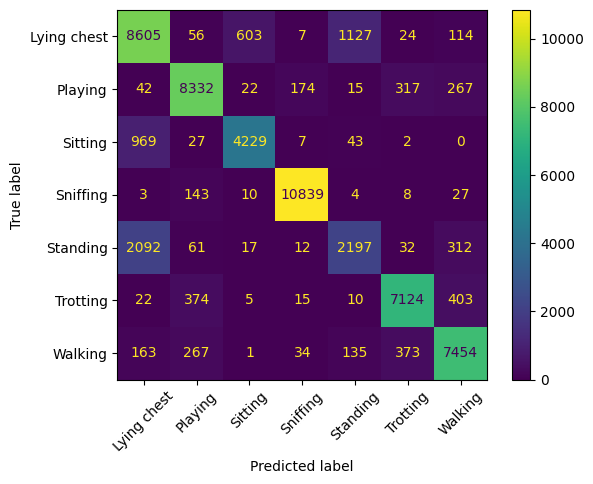

In [13]:
simple_learner = ydf.GradientBoostedTreesLearner(
    label="label",
    num_trees=100,
    task=ydf.Task.CLASSIFICATION
)

acc, f1, matrices, classes = lodo_validation(ds, simple_learner)

show_metrics(acc, f1, matrices, classes)

Com pesos nas classes

In [15]:
unique_classes, count = np.unique(ds["label"], return_counts=True)
total_sample = len(ds)
n_classes = len(unique_classes)

weights = {}
for cls, cnt in zip(unique_classes, count):
    weight = total_sample / (n_classes * cnt)
    weights[cls] = weight

Accuracy: 0.848885221383512
F1 Score (weighted): 0.8438445300609871
F1 Score (macro): 0.7854182303332817


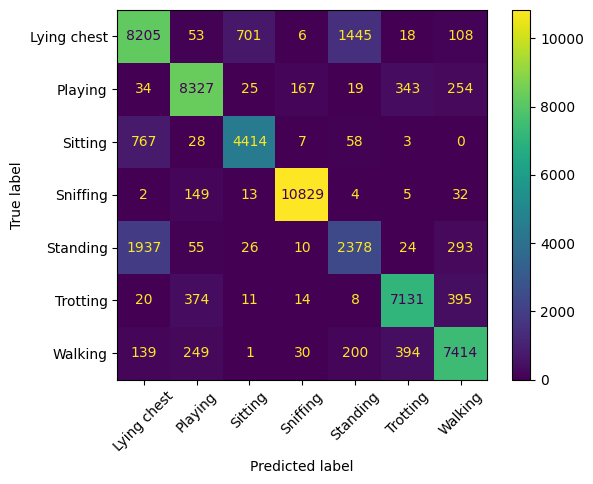

In [16]:
weighted_learner = ydf.GradientBoostedTreesLearner(
    label="label",
    num_trees=100,
    task=ydf.Task.CLASSIFICATION,
    class_weights=weights
)

acc, f1, matrices, classes = lodo_validation(ds, weighted_learner)

show_metrics(acc, f1, matrices, classes)

#### Com balanceamento artificial

undersampling

Accuracy: 0.8486606811941767
F1 Score (weighted): 0.8443659554155877
F1 Score (macro): 0.7876613164103007


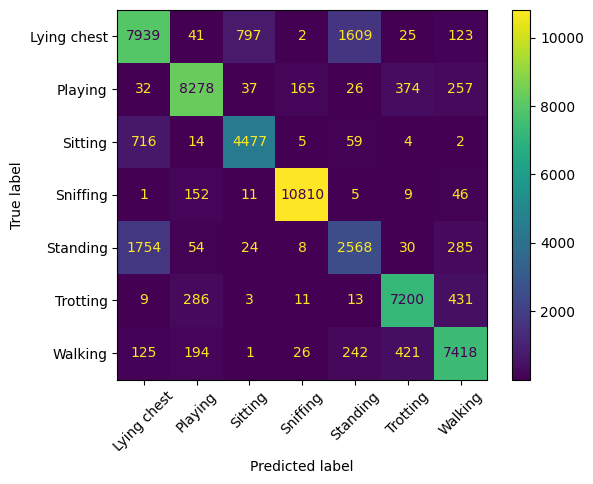

In [17]:
under_learner = ydf.GradientBoostedTreesLearner(
    label="label",
    num_trees=100,
    task=ydf.Task.CLASSIFICATION,
    num_threads=12
)

acc, f1, matrices, classes = lodo_validation_sampling(ds, under_learner, sampling='undersample')

show_metrics(acc, f1, matrices, classes)

Accuracy: 0.8488480576153904
F1 Score (weighted): 0.8441849755250705
F1 Score (macro): 0.7862750915307457


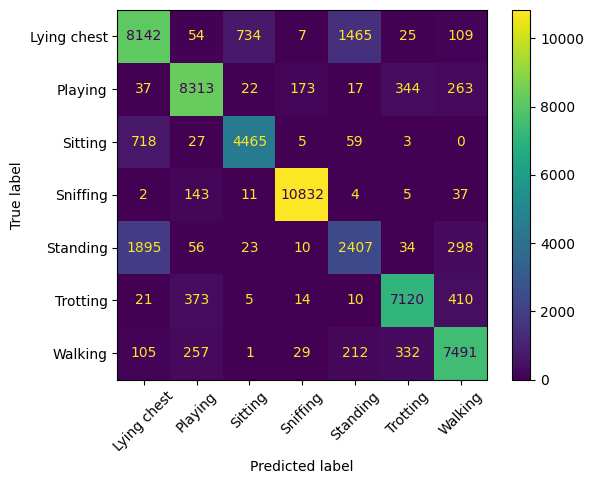

In [18]:
over_learner = ydf.GradientBoostedTreesLearner(
    label="label",
    num_trees=100,
    task=ydf.Task.CLASSIFICATION
)

acc, f1, matrices, classes = lodo_validation_sampling(ds, over_learner, sampling='oversample')

show_metrics(acc, f1, matrices, classes)

Accuracy: 0.8422377195683979
F1 Score (weighted): 0.8383454841035327
F1 Score (macro): 0.781175813404878


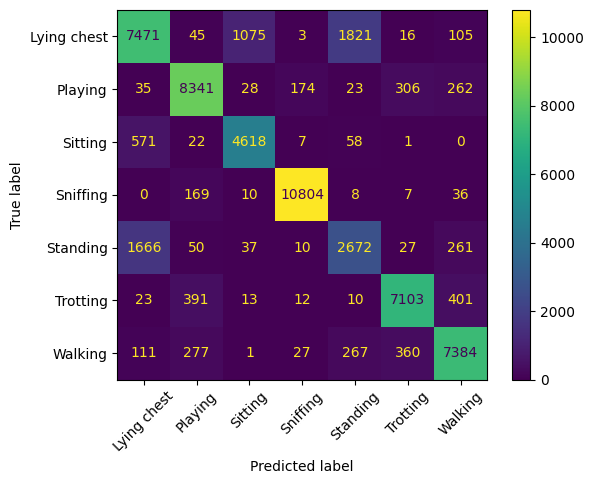

In [19]:
smote_learner = ydf.GradientBoostedTreesLearner(
    label="label",
    num_trees=100,
    task=ydf.Task.CLASSIFICATION
)

acc, f1, matrices, classes = lodo_validation_sampling(ds, smote_learner, sampling='smote')

show_metrics(acc, f1, matrices, classes)